```
<06_More_Apple_Classification.ipynb>

제미나이 의존도: 40-50%

859개의 데이터(신선한 사과와 상한 사과는 거의 1:1 비율에 가까움)로 Train / Test를 돌려보고
plt 라이브러리를 사용하여 실제로 어떤 이미지를 맞히고 어떤 이미지를 틀리는지 보았다.

구글 이미지를 크롤링 해올 때부터 이미 데이터 노이즈가 많이 섞여 있었다.
하지만 800여개의 사진을 일일이 확인하며 쓰레기 데이터를 버리기엔 시간이 너무 많이 소요된다.
정확도 100%를 찍는게 목표가 아니기에, 그냥 데이터 노이즈를 안고 가기로 했다.
아니나 다를까, plt로 출력한 이미지들을 보면 데이터 노이즈는 거의 못 맞히다시피 한다.(당연한 결과)
그래도 정제된 이미지는 높은 확률로 맞히는 걸 보고 엄청 신기했다.
예전에도 제미나이랑 같이 공부하면서 plt로 띄워보긴 했지만, 그때는 코드에 내 기여도가 너무 적었다.(거의 베껴 쓴 수준)
이번엔 나의 기여도가 높았기에 뿌듯했다.
```

In [1]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

data_dir = 'images/more_data'
categories = ['fresh_apple', 'rotten_apple']

data = []
for category in categories:
    folder_path = os.path.join(data_dir, category)
    for img_name in os.listdir(folder_path):
        if img_name.endswith(('.jpg')):
            data.append({
                'image_path': os.path.join(folder_path, img_name), 
                'label_name': category
            })

df = pd.DataFrame(data)
print(len(df))
print(df.iloc[0])

label_map = {name: i for i, name in enumerate(categories)}
df['label'] = df['label_name'].map(label_map)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train count: {len(train_df)}, Test Count: {len(test_df)}")

859
image_path    images/more_data/fresh_apple/fresh_316.jpg
label_name                                   fresh_apple
Name: 0, dtype: str
Train count: 687, Test Count: 172


In [2]:
!pwd

/Users/jeongjaehun/Crawling/02_crawling_data


In [3]:
import cv2
import torch
from torch.utils.data import Dataset
# import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

class AppleDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = int(row['label'])

        if self.transform:
            aug = self.transform(image=image)
            image = aug['image']

        return image, torch.tensor(label, dtype=torch.long)

# albumentations는 정규화(Normalize) 후 ToTensorV2를 적용합니다.
train_transform = A.Compose([
    A.Resize(128, 128), 
    # A.HorizontalFlip(p=0.5) # 나중에 train에만 별도로 추가하면 좋다.
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [4]:
from torch.utils.data import DataLoader

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"device: {device}")

train_dataset = AppleDataset(df=train_df, transform=train_transform)
test_dataset = AppleDataset(df=test_df, transform=train_transform)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device: mps


In [5]:
sample_img, sample_label = train_dataset[0]

print(f"이미지 타입: {type(sample_img)}")
print(f"라벨 타입: {type(sample_label)}")

이미지 타입: <class 'torch.Tensor'>
라벨 타입: <class 'torch.Tensor'>


In [6]:
images, labels = next(iter(train_dataloader))
print(f"image shape: {images.shape}, label shape: {labels.shape}")

image shape: torch.Size([32, 3, 128, 128]), label shape: torch.Size([32])


In [11]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__() # (32, 3, 128, 128) -> (32, 16, 64, 64) -> (32, 32, 32, 32) -> (32, 64, 16, 16)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.fc = nn.Linear(64 * 16 * 16, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = SimpleCNN().to(device)

In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
epochs = 5
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_dataloader.dataset):.4f}")

model.eval()
correct = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()

acc = correct / len(test_dataloader.dataset)
print(f"Acc: {acc * 100:.2f}")

Epoch 1/5 | Train Loss: 2.9213
Epoch 2/5 | Train Loss: 0.6323
Epoch 3/5 | Train Loss: 0.5114
Epoch 4/5 | Train Loss: 0.4094
Epoch 5/5 | Train Loss: 0.3833
Acc: 68.02


In [14]:
import torch
torch.save(model.state_dict(), 'simple_cnn_apple.pth')

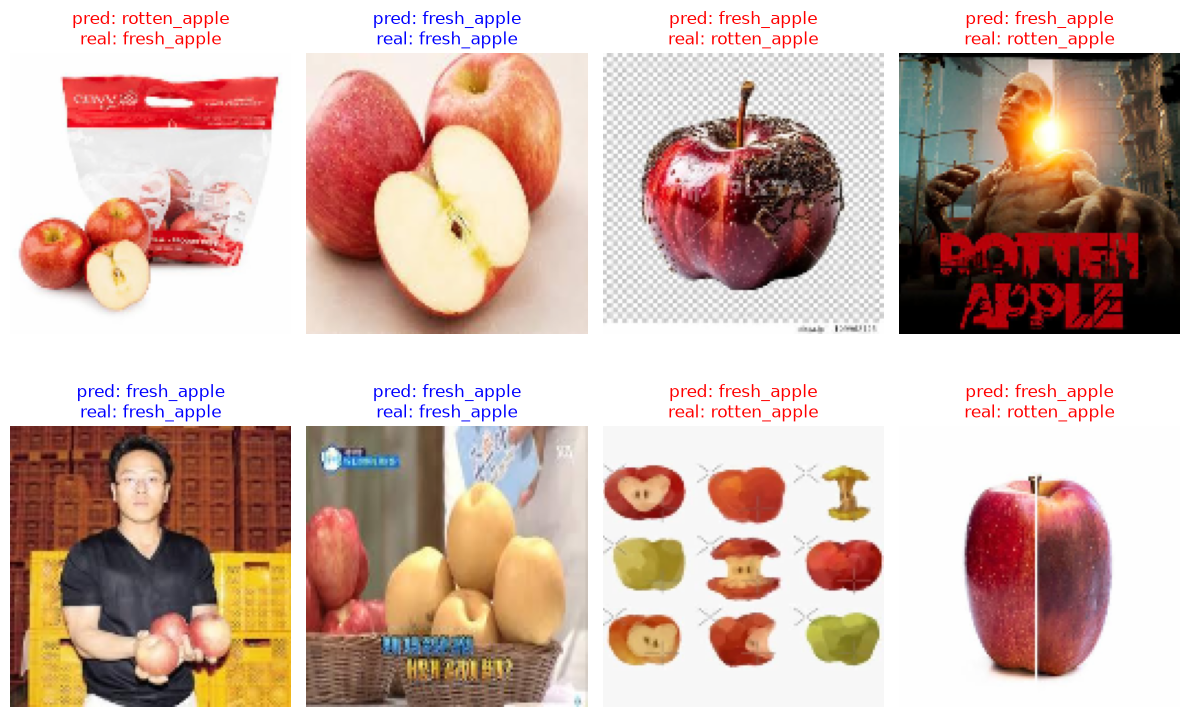

In [27]:
import matplotlib.pyplot as plt
import numpy as np

test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=True)
images, labels = next(iter(test_dataloader))

model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    preds = outputs.argmax(1)

plt.figure(figsize=(12, 8))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(8):
    color = 'red'
    if preds[i] == labels[i]:
        color = 'blue'
    else:
        color = 'red'
        
    img = images[i].permute(1, 2, 0).cpu().numpy() # 안전하게 numpy로 바꾼다.

    # 표준편차를 곱하고 평균을 더해 원본 픽셀로 복원한다.
    img = (img * std) + mean
    
    img = np.clip(img, 0, 1) # 0보다 작은 건 0으로, 1보다 큰 건 1로 깎아준다.
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"pred: {categories[preds[i]]}\nreal: {categories[labels[i]]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()